<a href="https://colab.research.google.com/github/jaeheechillin3/pytorch_projects/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
'''
1. MNIST dataset
2. Loading the dataset into Dataloader
3. Building the model with nn.Module
4. Training the classifier
'''

'\n1. MNIST dataset\n2. Loading the dataset into Dataloader\n3. Building the model with nn.Module\n4. Training the classifier\n'

In [9]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets

train_dataset = datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor())

In [10]:
print('Number of training samples: ' + str(len(train_dataset)))
print('Number of testing samples: ' + str(len(test_dataset)))
print('Training sample datatype: ', train_dataset[0][0].type())
print('Training sample size: ', train_dataset[0][0].size())

Number of training samples: 60000
Number of testing samples: 10000
Training sample datatype:  torch.FloatTensor
Training sample size:  torch.Size([1, 28, 28])


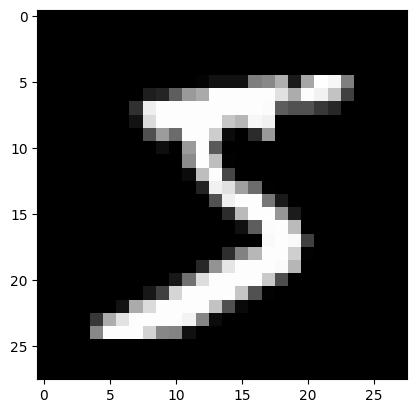

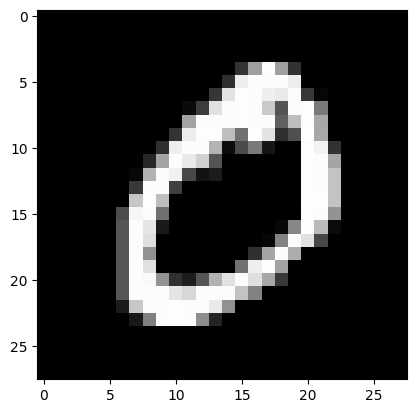

In [11]:
import matplotlib.pyplot as plt

first_sample_image = train_dataset[0][0].numpy().reshape(28, 28)
second_sample_image = train_dataset[1][0].numpy().reshape(28, 28)
plt.imshow(first_sample_image, cmap='gray')
plt.show()
plt.imshow(second_sample_image, cmap='gray')
plt.show()

In [12]:
# load dataset into DataLoader
from torch.utils.data import DataLoader

batch_size = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [14]:
# custom module for logistic regression
class LogisticRegression(torch.nn.Module):
  def __init__(self, n_inputs, n_outputs):
    super(LogisticRegression, self).__init__()
    self.linear = torch.nn.Linear(n_inputs, n_outputs)

  def forward(self, x):
    y_pred = torch.sigmoid(self.linear(x))
    return y_pred

In [16]:
n_inputs = 28*28
n_outputs = 10
log_regr = LogisticRegression(n_inputs, n_outputs)

In [20]:
# training the classifier
optimizer = torch.optim.SGD(log_regr.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

epochs = 50
Loss = []
acc = []

for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = log_regr(images.view(-1, 28*28))
        loss = criterion(outputs, labels)
        # Loss.append(loss.item())
        loss.backward()
        optimizer.step()
    Loss.append(loss.item())
    correct = 0
    for images, labels in test_loader:
        outputs = log_regr(images.view(-1, 28*28))
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum()
    accuracy = 100 * (correct.item()) / len(test_dataset)
    acc.append(accuracy)
    print('Epoch: {}. Loss: {}. Accuracy: {}'.format(epoch, loss.item(), accuracy))

Epoch: 0. Loss: 1.821239709854126. Accuracy: 82.56
Epoch: 1. Loss: 1.8449894189834595. Accuracy: 82.77
Epoch: 2. Loss: 1.8014708757400513. Accuracy: 83.09
Epoch: 3. Loss: 1.8066903352737427. Accuracy: 83.34
Epoch: 4. Loss: 1.8261173963546753. Accuracy: 83.43
Epoch: 5. Loss: 1.805725336074829. Accuracy: 83.56
Epoch: 6. Loss: 1.8074569702148438. Accuracy: 83.77
Epoch: 7. Loss: 1.8099666833877563. Accuracy: 83.9
Epoch: 8. Loss: 1.8198838233947754. Accuracy: 84.0
Epoch: 9. Loss: 1.8621909618377686. Accuracy: 84.01
Epoch: 10. Loss: 1.7984938621520996. Accuracy: 84.16
Epoch: 11. Loss: 1.7298890352249146. Accuracy: 84.25
Epoch: 12. Loss: 1.730413794517517. Accuracy: 84.39
Epoch: 13. Loss: 1.8495502471923828. Accuracy: 84.52
Epoch: 14. Loss: 1.8229175806045532. Accuracy: 84.64
Epoch: 15. Loss: 1.779099702835083. Accuracy: 84.77
Epoch: 16. Loss: 1.7680132389068604. Accuracy: 84.93
Epoch: 17. Loss: 1.7805533409118652. Accuracy: 85.05
Epoch: 18. Loss: 1.7255979776382446. Accuracy: 85.15
Epoch: 19

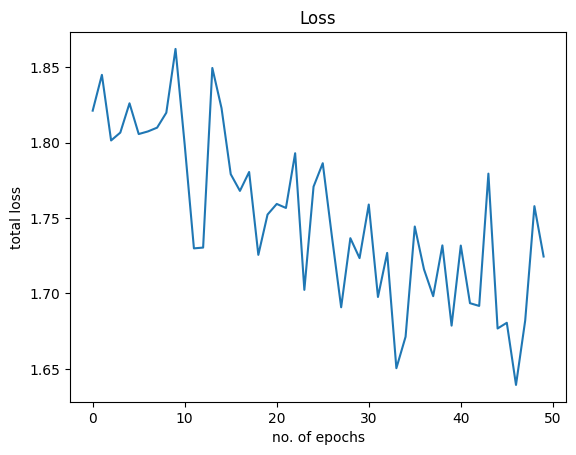

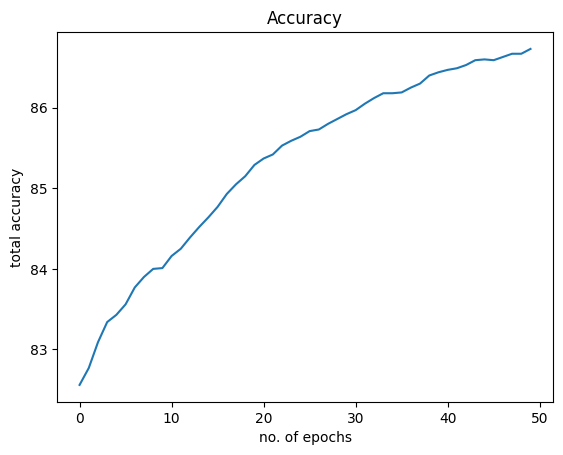

In [21]:
# graph the results
plt.plot(Loss)
plt.xlabel('no. of epochs')
plt.ylabel('total loss')
plt.title('Loss')
plt.show()

plt.plot(acc)
plt.xlabel('no. of epochs')
plt.ylabel('total accuracy')
plt.title('Accuracy')
plt.show()